# 🧠 Notebook 05 — Visual CNN (EfficientNet-B4 + Grad-CAM)
Person 1

In [11]:
# ✅ Verify GPU is available and force CUDA
import torch

print(f"CUDA available : {torch.cuda.is_available()}")
print(f"GPU name       : {torch.cuda.get_device_name(0)}")
print(f"GPU memory     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Force device to cuda
DEVICE = "cuda"
torch.cuda.empty_cache()

# Quick speed test
x = torch.randn(1000, 1000).to(DEVICE)
y = torch.randn(1000, 1000).to(DEVICE)
z = torch.mm(x, y)
print(f"\n✅ GPU test passed — matrix multiply done on {DEVICE}")

CUDA available : True
GPU name       : Tesla T4
GPU memory     : 15.6 GB

✅ GPU test passed — matrix multiply done on cuda


In [12]:
!pip install torch torchvision tqdm scikit-learn -q

# Check what GPU you have

In [13]:
from google.colab import drive
drive.mount('/content/drive')

import os, random, numpy as np, cv2, torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights
from pathlib import Path
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import accuracy_score, roc_auc_score
import matplotlib.pyplot as plt

BASE_DIR    = "/content/drive/MyDrive/Colab Notebooks/deepfake-project"
FACES_DIR   = os.path.join(BASE_DIR, "data/faces")
MODEL_DIR   = os.path.join(BASE_DIR, "models")
HEATMAP_DIR = os.path.join(BASE_DIR, "outputs/heatmaps")
os.makedirs(MODEL_DIR,   exist_ok=True)
os.makedirs(HEATMAP_DIR, exist_ok=True)

DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 64 ; EPOCHS = 15; LR = 1e-4; IMG_SIZE = 224; SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print(f"✅ Device: {DEVICE}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Device: cuda


In [14]:
# ✅ Dataset
class FaceDataset(Dataset):
    def __init__(self, file_list, labels, transform=None):
        self.files = file_list; self.labels = labels; self.transform = transform
    def __len__(self): return len(self.files)
    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, torch.tensor(self.labels[idx], dtype=torch.float32)

def build_dataset(faces_dir, val_split=0.15, test_split=0.10):
    fakes = list(Path(faces_dir).glob("fake*/*.jpg")) + list(Path(faces_dir).glob("fake/*.jpg"))
    reals = list(Path(faces_dir).glob("real*/*.jpg")) + list(Path(faces_dir).glob("real/*.jpg"))
    n = min(len(fakes), len(reals))
    fakes, reals = random.sample(fakes, n), random.sample(reals, n)
    files  = [str(f) for f in fakes + reals]
    labels = [1]*len(fakes) + [0]*len(reals)
    combined = list(zip(files, labels)); random.shuffle(combined)
    files, labels = zip(*combined)
    n_total = len(files)
    n_val   = int(n_total * val_split)
    n_test  = int(n_total * test_split)
    return (
        (list(files[n_val+n_test:]), list(labels[n_val+n_test:])),
        (list(files[:n_val]),         list(labels[:n_val])),
        (list(files[n_val:n_val+n_test]), list(labels[n_val:n_val+n_test])),
    )

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

(tr_f,tr_l),(v_f,v_l),(te_f,te_l) = build_dataset(FACES_DIR)
train_dl = DataLoader(FaceDataset(tr_f,tr_l,train_tf), batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_dl   = DataLoader(FaceDataset(v_f, v_l, val_tf),   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_dl  = DataLoader(FaceDataset(te_f,te_l,val_tf),   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print(f"✅ Train: {{len(tr_f)}}, Val: {{len(v_f)}}, Test: {{len(te_f)}}")

✅ Train: {len(tr_f)}, Val: {len(v_f)}, Test: {len(te_f)}


In [15]:
# ✅ EfficientNet-B4 Model with Grad-CAM hooks
class VisualCNN(nn.Module):
    def __init__(self):
        super().__init__()
        backbone        = efficientnet_b4(weights=EfficientNet_B4_Weights.IMAGENET1K_V1)
        self.features   = backbone.features
        self.pool       = nn.AdaptiveAvgPool2d(1)
        in_f            = backbone.classifier[1].in_features
        self.classifier = nn.Sequential(
            nn.Dropout(0.5), nn.Linear(in_f, 512), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(512, 1),
        )
        self.gradients = None; self.activations = None
        self.features[-1].register_forward_hook(lambda m,i,o: setattr(self,'activations',o))
        self.features[-1].register_backward_hook(lambda m,i,o: setattr(self,'gradients',o[0]))
    def forward(self, x):
        f = self.pool(self.features(x)).flatten(1)
        return self.classifier(f).squeeze(1)

model     = VisualCNN().to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.BCEWithLogitsLoss()
print("✅ Model ready.")

✅ Model ready.


In [16]:
# ✅ Training Loop
best_auc = 0.0
for epoch in range(1, EPOCHS + 1):
    model.train(); tr_loss = 0
    for imgs, lbls in tqdm(train_dl, desc=f"Epoch {epoch}/{EPOCHS} [train]"):
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(imgs), lbls)
        loss.backward(); optimizer.step()
        tr_loss += loss.item()
    scheduler.step()
    model.eval(); all_probs, all_lbls = [], []
    with torch.no_grad():
        for imgs, lbls in val_dl:
            probs = torch.sigmoid(model(imgs.to(DEVICE))).cpu().numpy()
            all_probs.extend(probs); all_lbls.extend(lbls.numpy())
    auc = roc_auc_score(all_lbls, all_probs)
    acc = accuracy_score(all_lbls, [p>0.5 for p in all_probs])
    print(f"  Epoch {epoch}: loss={tr_loss/len(train_dl):.4f}  val_acc={acc:.4f}  val_auc={auc:.4f}")
    if auc > best_auc:
        best_auc = auc
        torch.save(model.state_dict(), os.path.join(MODEL_DIR, "visual_cnn.pth"))
        print("  ✔ Saved best model")
print(f"\n✅ Training complete. Best AUC: {best_auc:.4f}")

Epoch 1/15 [train]: 100%|██████████| 136/136 [13:19<00:00,  5.88s/it]


  Epoch 1: loss=0.4845  val_acc=0.9104  val_auc=0.9757
  ✔ Saved best model


Epoch 2/15 [train]:   0%|          | 0/136 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)
Epoch 2/15 [train]: 100%|██████████| 136/136 [02:07<00:00,  1.07it/s]


  Epoch 2: loss=0.1558  val_acc=0.9659  val_auc=0.9954
  ✔ Saved best model


Epoch 3/15 [train]:   0%|          | 0/136 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)
Epoch 3/15 [train]: 100%|██████████| 136/136 [02:06<00:00,  1.07it/s]


...

  Epoch 13: loss=0.0105  val_acc=0.9925  val_auc=0.9998
  ✔ Saved best model


Epoch 14/15 [train]:   0%|          | 0/136 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)
Epoch 14/15 [train]: 100%|██████████| 136/136 [02:06<00:00,  1.07it/s]


  Epoch 14: loss=0.0127  val_acc=0.9913  val_auc=0.9997


Epoch 15/15 [train]:   0%|          | 0/136 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)
Epoch 15/15 [train]: 100%|██████████| 136/136 [02:06<00:00,  1.08it/s]


  Epoch 15: loss=0.0113  val_acc=0.9925  val_auc=0.9998

✅ Training complete. Best AUC: 0.9998


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


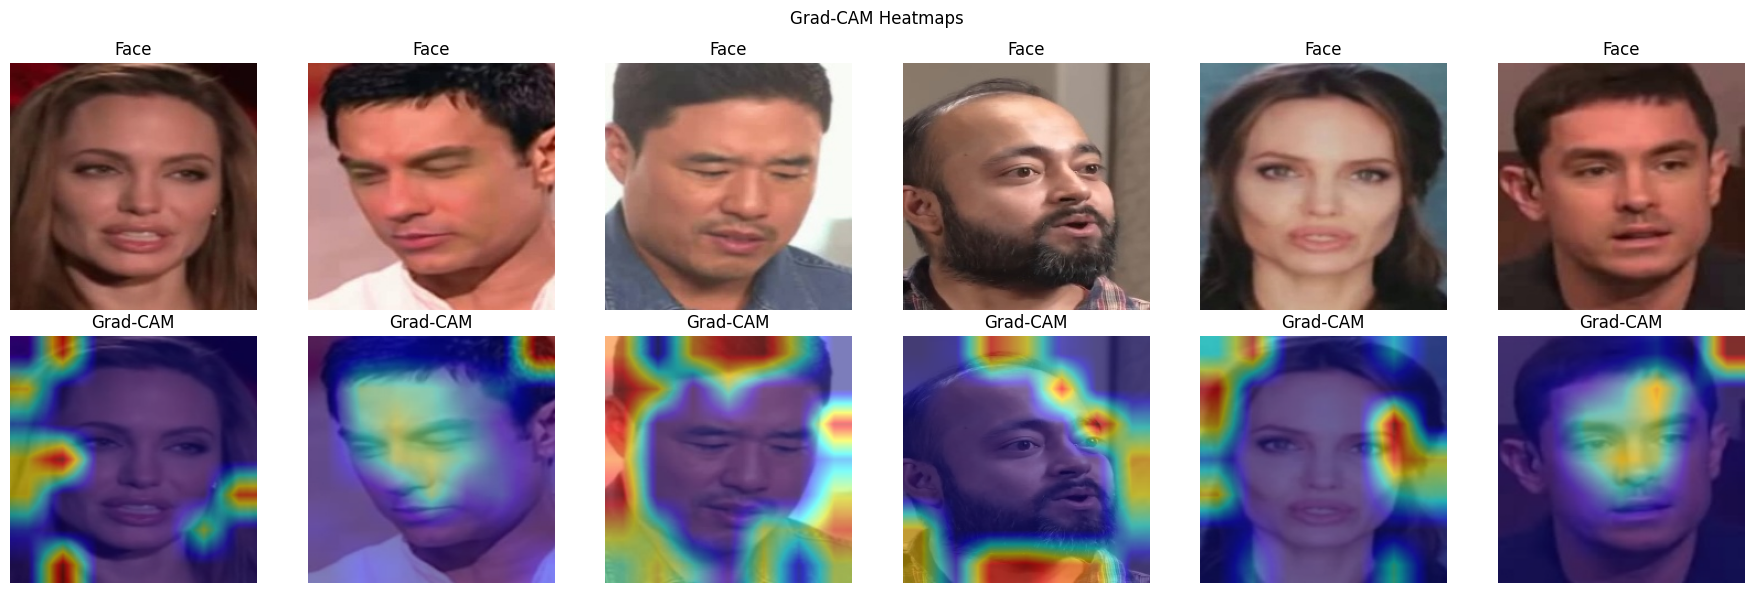

✅ Heatmaps saved to /content/drive/MyDrive/Colab Notebooks/deepfake-project/outputs/heatmaps


In [17]:
# ✅ Grad-CAM + Save Heatmaps
def grad_cam(model, img_tensor):
    model.eval()
    img_tensor = img_tensor.to(DEVICE).unsqueeze(0).requires_grad_(True)
    out = model(img_tensor); model.zero_grad(); out.backward()
    grads  = model.gradients.detach().cpu()
    acts   = model.activations.detach().cpu()
    weights = grads.mean(dim=[2,3], keepdim=True)
    cam    = (weights * acts).sum(dim=1).squeeze()
    cam    = torch.relu(cam).numpy()
    cam    = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    cam    = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam

model.load_state_dict(torch.load(os.path.join(MODEL_DIR, "visual_cnn.pth"), map_location=DEVICE))
sample_faces = random.sample(te_f, min(6, len(te_f)))
fig, axes    = plt.subplots(2, len(sample_faces), figsize=(3*len(sample_faces), 6))
mean = np.array([0.485,0.456,0.406]); std = np.array([0.229,0.224,0.225])
for i, fp in enumerate(sample_faces):
    img_pil = Image.open(fp).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    img_np  = np.array(img_pil)
    cam     = grad_cam(model, val_tf(img_pil))
    heatmap = cv2.applyColorMap((cam*255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = (0.5*img_np + 0.5*heatmap).astype(np.uint8)
    axes[0,i].imshow(img_np);  axes[0,i].axis("off"); axes[0,i].set_title("Face")
    axes[1,i].imshow(overlay); axes[1,i].axis("off"); axes[1,i].set_title("Grad-CAM")
    # Save to drive
    out_path = os.path.join(HEATMAP_DIR, Path(fp).stem+"_gradcam.jpg")
    cv2.imwrite(out_path, cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))
plt.suptitle("Grad-CAM Heatmaps"); plt.tight_layout(); plt.show()
print(f"✅ Heatmaps saved to {HEATMAP_DIR}")

In [18]:
# ✅ Test Evaluation
model.eval(); probs, lbls = [], []
with torch.no_grad():
    for imgs, l in test_dl:
        p = torch.sigmoid(model(imgs.to(DEVICE))).cpu().numpy()
        probs.extend(p); lbls.extend(l.numpy())
print(f"\n=== Final Test Results ===")
print(f"  Accuracy : {accuracy_score(lbls, [p>0.5 for p in probs]):.4f}")
print(f"  AUC      : {roc_auc_score(lbls, probs):.4f}")


=== Final Test Results ===
  Accuracy : 0.9913
  AUC      : 0.9997
